# PCA
En este laboratorio vamos a usar PCA (o Análisis de Componente Principal) para proyectar data bidimensional a sus ejes principales y hacer reducciónes en general de dimensiones altas a bajas.

### SETUP
Primero vamos a descargar e importar las dependencias

In [1]:
!pip install -q numpy==2.2.0
!pip install -q scikit-learn==1.6.0
!pip install -q matplotlib==3.9.3

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn import datasets
from sklearn.preprocessing import StandardScaler

Luego vamos a crear una matriz de 2 dimensiones para usar como dataset, notemos que los features van a estar linealmente relacionados

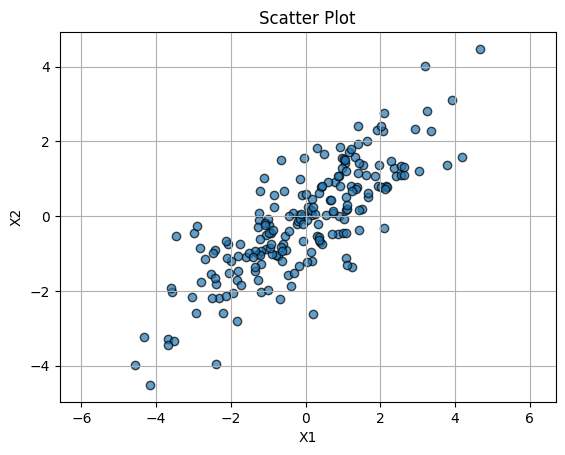

In [3]:
np.random.seed(35)
mean = [0, 0]
cov = [[3, 2], [2, 2]]
X = np.random.multivariate_normal(mean=mean, cov=cov, size=200)

plt.figure()
plt.scatter(X[:,0], X[:,1], edgecolor='k', alpha=0.7)
plt.title("Scatter Plot")
plt.xlabel("X1")
plt.ylabel("X2")
plt.axis('equal')
plt.grid(True)
plt.show()

## Proyeccion a componentes principales
Utilicemos el modelo PCA para proyectar nuestro dataset a sus componentes principales, primero armamos el modelo y lo ajustamos. Es importante tener en cuenta la cantidad de componentes, dada una matriz NxN tendremos N componentes.

In [4]:
# Armamos el modelo y ajustamos
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Obtenemos componentes ppales.
components = pca.components_
print(f"Componentes: {components}")

Componentes: [[ 0.78332946  0.62160675]
 [-0.62160675  0.78332946]]


Estas componentes indican las direcciones de máxima variación en nuestro "dataset". <br>
Una vez hecho esto podemos utilizar nuevamente un scatterplot para visualizar los datapoints originales en su espacio inicial y proyectados sobre las direcciones de sus componentes principales.

### Proyectar
Para proyectar los datos sabemos utilizar operaciones de Algebra Lineal, por lo tanto podemos calcular dichas proyecciones mediante productos entre los datapoints y las componentes. <br> 
Voy a generalizar la función de calculo de proyecciones y reconstrucción. Para facilitar un poco el ploteo voy a dejarlo en un esquema 2D.

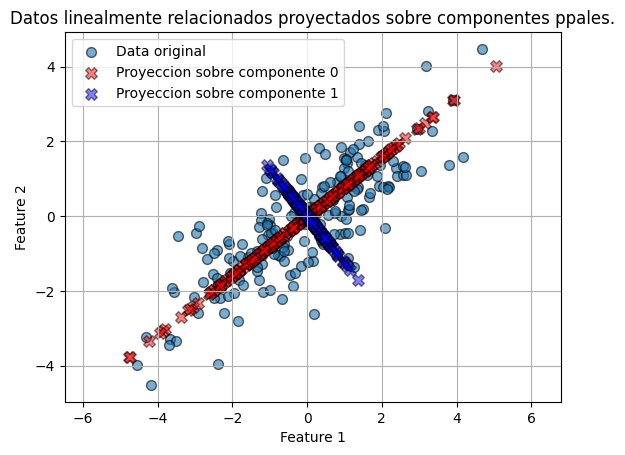

In [16]:
projections = []
component_count = len(components)
for i in range(component_count):
    projections.append( np.dot(X,components[i]))

reconstruction = []
for i in range(component_count):
    vector = []
    for j in range(component_count):
        vector.append( projections[i] * components[i][j])
    reconstruction.append(vector)


# Ploteamos datos originales
plt.figure()
plt.scatter(X[:, 0], X[:, 1], label='Data original', ec='k', s=50, alpha=0.6)

# Ploteamos proyecciones
plt.scatter(reconstruction[0][0],reconstruction[0][1], c='r', ec='k', marker='X', s=70, alpha=0.5, label=f'Proyeccion sobre componente 0')
plt.scatter(reconstruction[1][0],reconstruction[1][1], c='b', ec='k', marker='X', s=70, alpha=0.5, label=f'Proyeccion sobre componente 1')
plt.title('Datos linealmente relacionados proyectados sobre componentes ppales.', )
plt.xlabel('Feature 1',)
plt.ylabel('Feature 2',)
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

## Reduccion de dimensiones
Ahora utilicemos el modelo PCA para proyectar un dataset de 4 dimensiones a uno de 2.  
<br>
Carguemos y preparemos el dataset, notemos que el conjunto de datos contiene muestras de 3 especies de Iris, en el cual se miden 3 rasgos de cada muestra: <br>
Largo de sépalo, Ancho de sépalo, Largo de pétalo, Ancho de pétalo.

In [23]:
# Cargamos dataset
dataset = datasets.load_iris()
X = dataset.data
y = dataset.target
target_names = dataset.target_names
print(f"Features: {target_names}")

# Estandarizamos el dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Features: ['setosa' 'versicolor' 'virginica']


Ahora armemos nuestor modelo PCA y reduzcamos nuestras componentes, luego visualicemos el resultado de la reducción

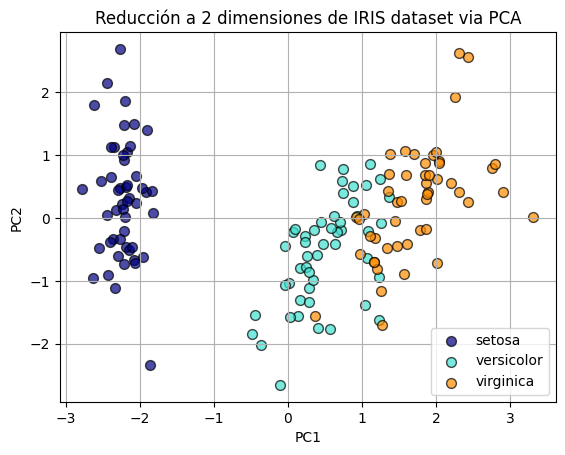

In [21]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Ploteamos data a 2D
plt.figure()

colors = ['navy', 'turquoise', 'darkorange']
lw = 1

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], color=color, s=50, ec='k',alpha=0.7, lw=lw,
                label=target_name)

plt.title('Reducción a 2 dimensiones de IRIS dataset via PCA',)
plt.xlabel("PC1",)
plt.ylabel("PC2",)
plt.legend(loc='best', shadow=False, scatterpoints=1,)
plt.grid(True)
plt.show()

Podemos observar una superposición en las categorías versicolor y virginica. Podemos entonces analizar cuales de las componentes nos muestran una mayor variación a fin de determinar si aplicar una reducción más leve nos otorgaría mas información.

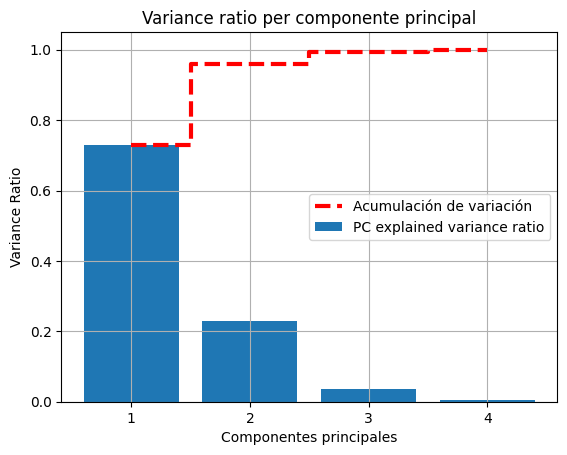

In [27]:
X_scaled = scaler.fit_transform(X)

# Armamos PCA sin reducción de componentes
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

# Calculamos variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Ploteamos 
plt.figure()
plt.bar(x=range(1, len(explained_variance_ratio)+1), height=explained_variance_ratio, alpha=1, align='center', label='PC explained variance ratio' )
plt.ylabel('Variance Ratio')
plt.xlabel('Componentes principales')
plt.title('Variance ratio per componente principal')

# Ploteamos acumulación de variance ratio
cumulative_variance = np.cumsum(explained_variance_ratio)
plt.step(range(1, 5), cumulative_variance, where='mid', linestyle='--', lw=3,color='red', label='Acumulación de variación')
plt.xticks(range(1, 5))
plt.legend()
plt.grid(True)
plt.show()

Con esto observamos que en realidad la mayor ganancia de información esta en las componentes 1 y 2, mientras que las 3 y 4 aportan poco o nada de información nueva y pueden considerarse fundamentalmente ruido.